# FAONet Example
This notebook demonstrates how to use the FAONet package to load, filter and analyze FAOSTAT trade data.

First, we import the necessary libraries

In [1]:
from faonet.io import load_file
from faonet.plots import plot_trade_scatter, plot_bipartite_network2, plot_bipartite_network_enhanced, plot_degree_bar, plot_degree_comparison, plot_degree_by_rank, plot_degree_rank_multiyear, plot_weight_matrix
from faonet.plots import plot_top_betweenness, plot_mean_clustering_ratio_vs_degree, plot_clustering_ratio_multiyear
from faonet.plots import plot_betweenness_heatmap
from faonet.filtering import filter_top_percentile
from faonet.network import build_bipartite_network, remove_zero_weight_edges
from faonet.metrics import degree_by_group, compute_degree_and_strength, compute_betweenness_all, compute_bipartite_clustering
from faonet.export import export_gml
from faonet.fitting import fit_truncated_power_law, fit_strength_vs_degree



We load the file and choose the year we want to process

In [ ]:
# Example filepaths
file = '/Data/Green_Coffe_FAO_allyears.csv'
year = 2023
df = load_file(file, year = year)

## Clean up the market
Since we have country codes, we can colorize the interactions between countries, using color as the interaction value.

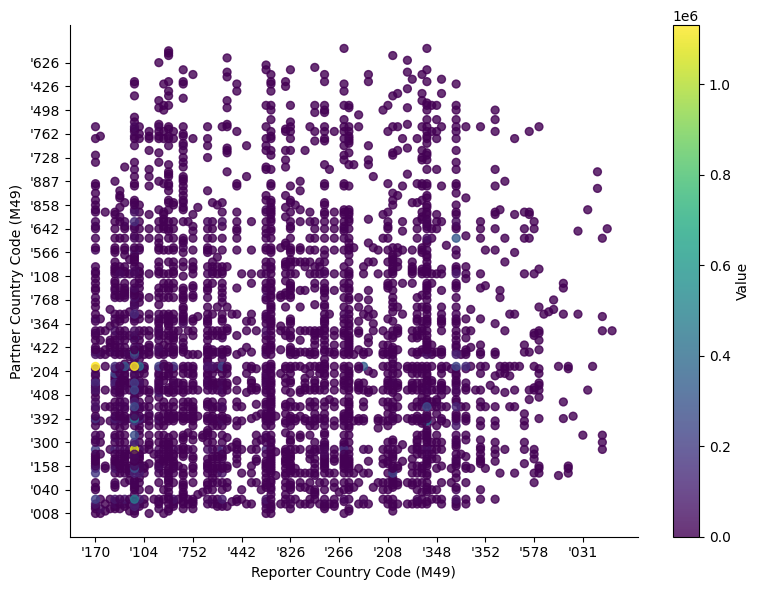

<Axes: xlabel='Reporter Country Code (M49)', ylabel='Partner Country Code (M49)'>

In [3]:
plot_trade_scatter(df)

We see that there are many very low values ​​(many purple colors) this tells us that it would be interesting to keep a percentage of the market that would allow us to better see the interactions and clean up many small interactions

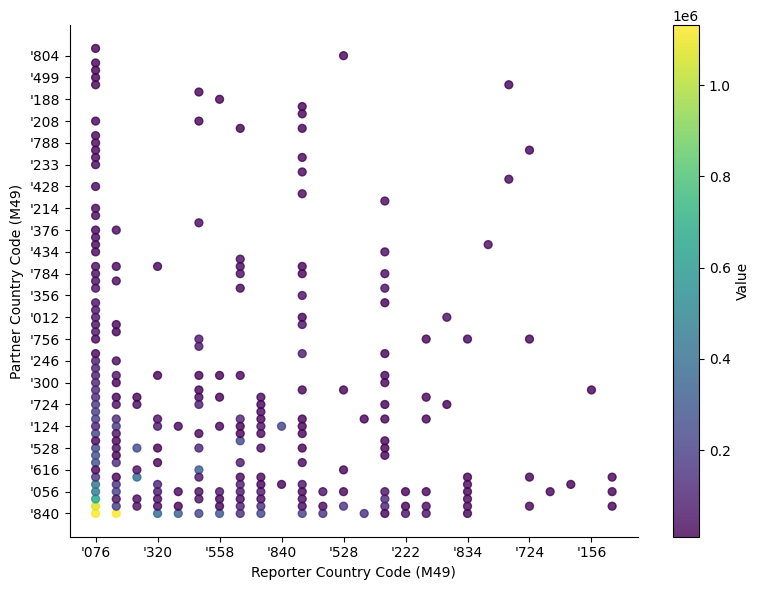

<Axes: xlabel='Reporter Country Code (M49)', ylabel='Partner Country Code (M49)'>

In [4]:
df_filtered = filter_top_percentile(df, value_column= 'Value', percentile=0.9)
plot_trade_scatter(df_filtered, step = 3)

**Now**, it seems the information is more interesting and we have left 90% of the international coffee market.

## We built the network of interactions

We built a bipartite network, with exporting and importing countries. The link width depends on the dollar value of the export.

To avoid confusion between country names, as there may be countries that act as both exporters and importers, we add '_e' to the "Reporter Countries".

In [5]:
df_filtered['Reporter Countries'] = df_filtered['Reporter Countries'] + "_e"
df_filtered.head()

,Unnamed: 0,Reporter Country Code,Reporter Country Code (M49),Reporter Countries,Partner Country Code,Partner Country Code (M49),Partner Countries,Item Code,Item Code (CPC),Item,Element Code,Element,Year Code,Year,Unit,Value,Flag,cumsum,cumperc
52864,38953253,21,'076,Brazil_e,231,'840,United States of America,656,'01610,"Coffee, green",5922,Export value,2023,2023,1000 USD,1131151.0,A,1131151.0,0.054722
36950,23427063,44,'170,Colombia_e,231,'840,United States of America,656,'01610,"Coffee, green",5922,Export value,2023,2023,1000 USD,1127220.0,A,2258371.0,0.109254
37653,24248644,21,'076,Brazil_e,79,'276,Germany,656,'01610,"Coffee, green",5922,Export value,2023,2023,1000 USD,1071001.0,A,3329372.0,0.161066
41109,27807596,21,'076,Brazil_e,106,'380,Italy,656,'01610,"Coffee, green",5922,Export value,2023,2023,1000 USD,664176.0,A,3993548.0,0.193197
15437,9600448,21,'076,Brazil_e,255,'056,Belgium,656,'01610,"Coffee, green",5922,Export value,2023,2023,1000 USD,460337.0,A,4453885.0,0.215467


In [6]:

# Build network
G, exporters, importers = build_bipartite_network(df_filtered, 'Reporter Countries', 'Partner Countries', 'Value')
G = remove_zero_weight_edges(G)

<Axes: title={'center': 'Bipartite Network: Exporters vs Importers'}>

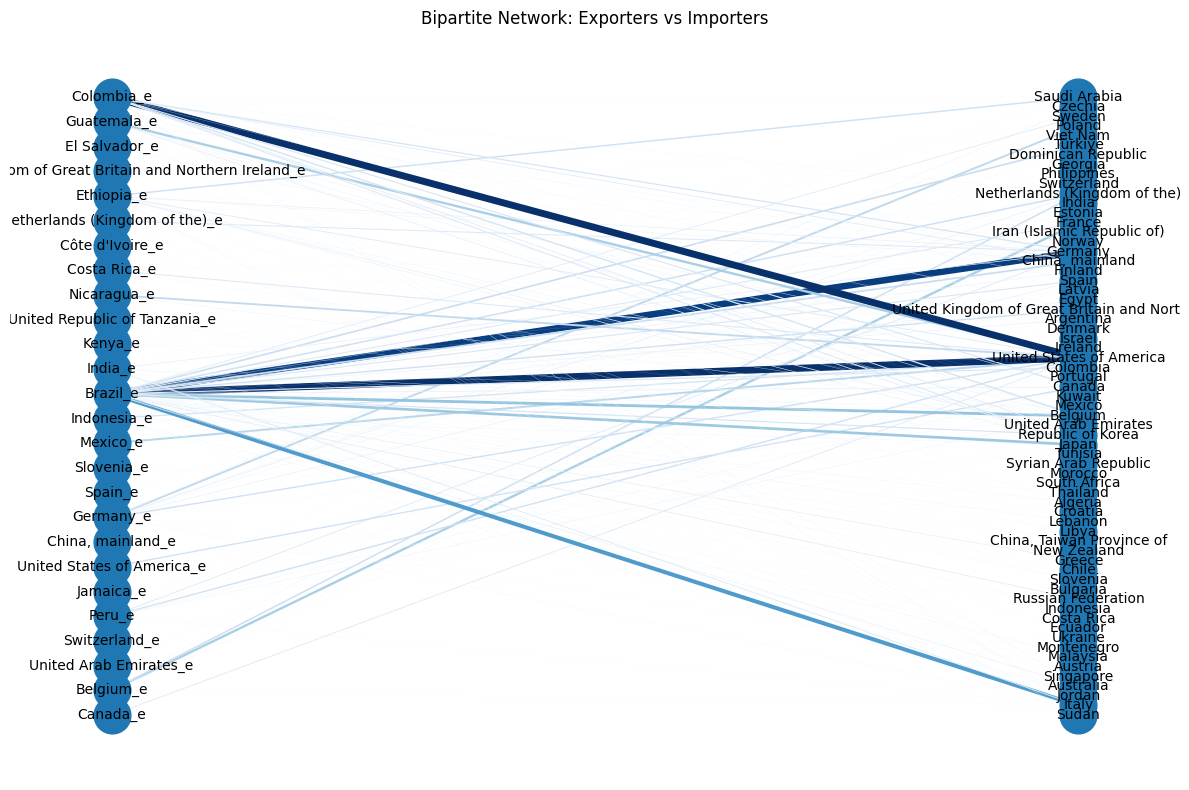

In [7]:

plot_bipartite_network2(G, group0_nodes=exporters, title="Bipartite Network: Exporters vs Importers")

<Axes: title={'center': 'Bipartite Network: Exporters vs Importers in 2023'}>

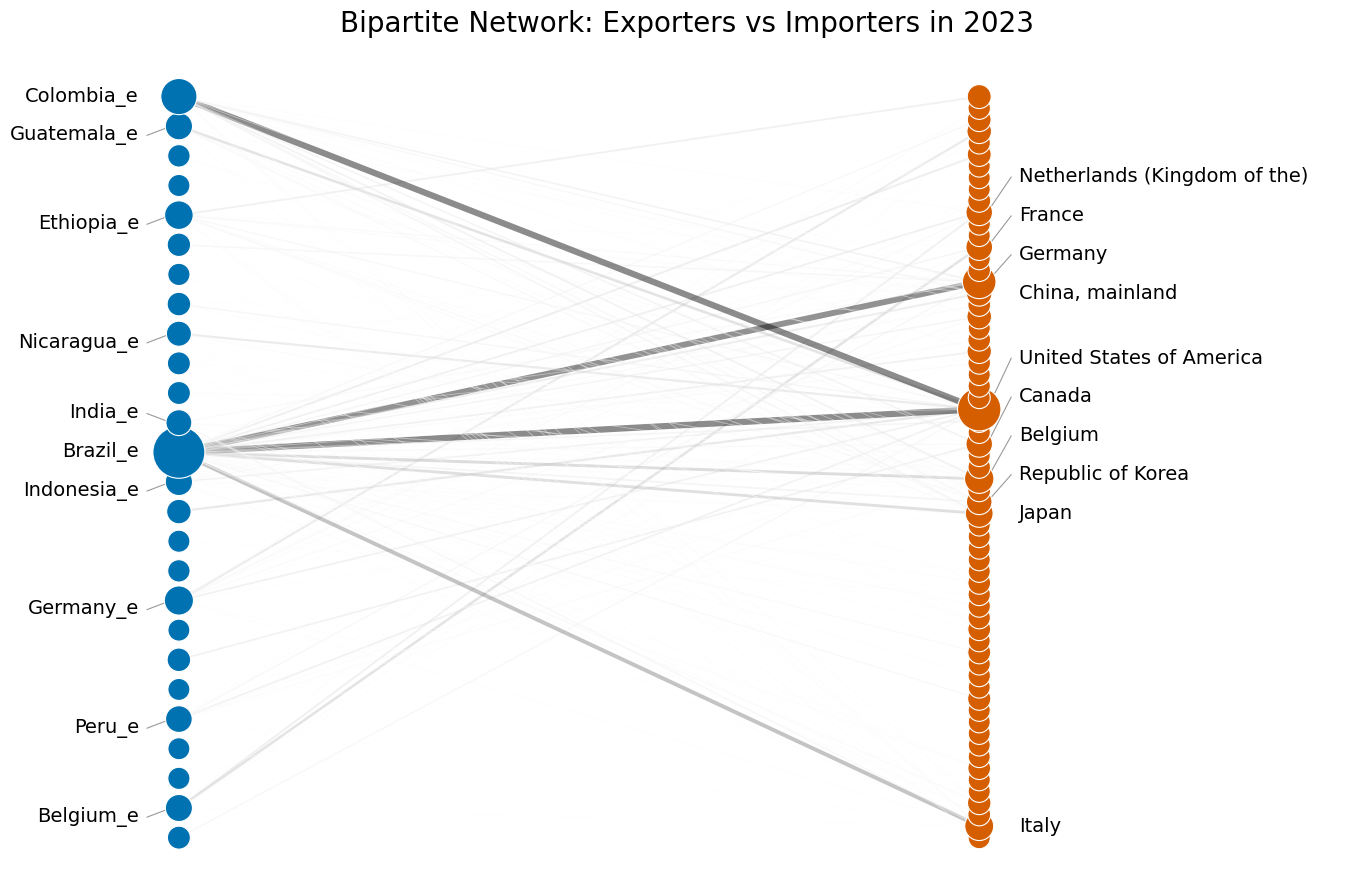

In [8]:

plot_bipartite_network_enhanced(
    G,
    group0_nodes=exporters,
    title="Bipartite Network: Exporters vs Importers in 2023",
    label_top_n=10,
    node_size_mode="strength",
    font_size=14,
    title_font_size=20,
    partition_gap=1.0,
    label_offset=0.05,
    x_margin_right=0.45,
    save_path='bipartite_network_2023'
)



In [9]:
# Export to GML
export_gml(G, 'trade_network.gml')

## Studying the Properties of Bipartite Networks

### Degree
The first thing usually studied is the degree of the networks. In this case, since they are bipartite, we must study the in-degree and out-degree.

Remember that the degree is the number of incoming or outgoing links, that is, the number of countries that export (out-degree) out of the number of countries that import (in-degree).

To study this, we do the following:

We calculate the degrees of exporters and importers.
We plot the histograms with the countries sorted by their degree.

In [29]:
# Compute degree
degree_export = degree_by_group(G, exporters)
print(degree_export.head())

degree_import = degree_by_group(G, importers)
print(degree_import.head())

                     Node  Degree
0                Canada_e       2
1               Belgium_e       7
2  United Arab Emirates_e       2
3           Switzerland_e       1
4                  Peru_e      13
        Node  Degree
0      Sudan       1
1      Italy      11
2     Jordan       3
3  Australia       7
4  Singapore       2


### Degree Distribution Graphs

To get an idea of ​​network behavior, one of the most interesting variables is to plot degree distributions.

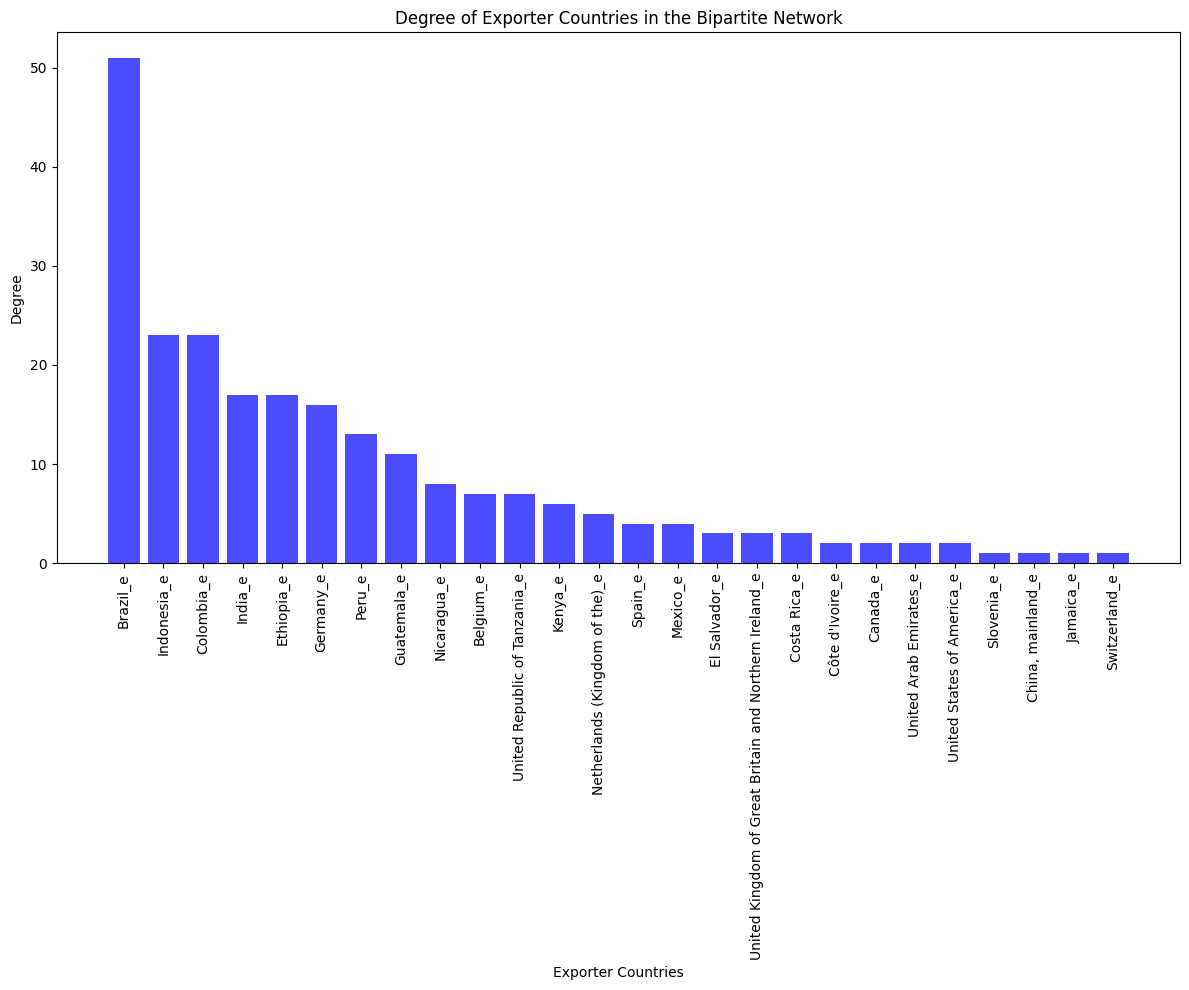

<Axes: title={'center': 'Degree of Exporter Countries in the Bipartite Network'}, xlabel='Exporter Countries', ylabel='Degree'>

In [30]:
plot_degree_bar(degree_export,
                country_col="Node",
                degree_col="Degree",
                figsize=(12, 10),
                title="Degree of Exporter Countries in the Bipartite Network",
                xlabel="Exporter Countries",
                ylabel="Degree")

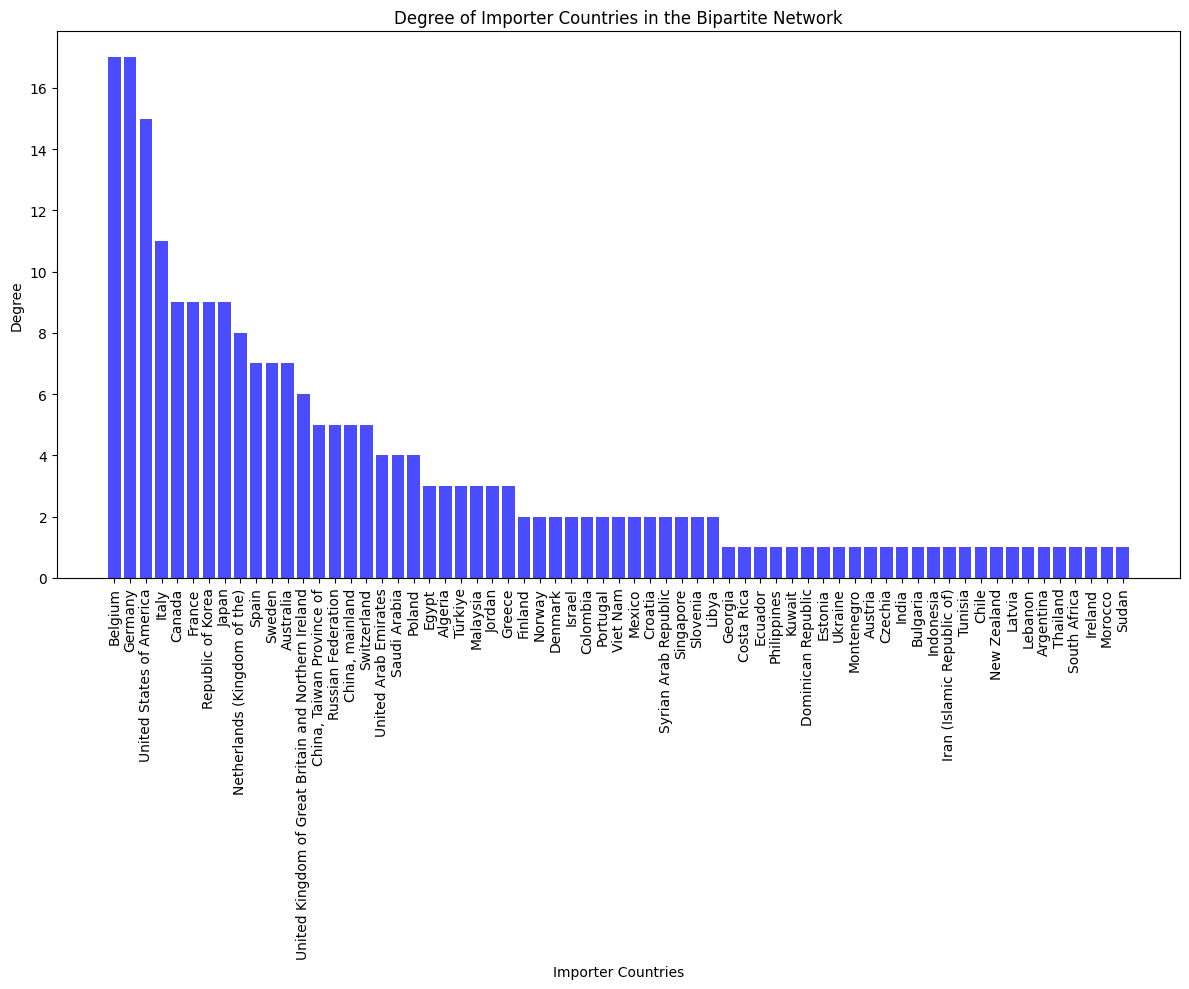

<Axes: title={'center': 'Degree of Importer Countries in the Bipartite Network'}, xlabel='Importer Countries', ylabel='Degree'>

In [31]:

plot_degree_bar(degree_import,
                country_col="Node",
                degree_col="Degree",
                figsize=(12, 10),
                title="Degree of Importer Countries in the Bipartite Network",
                xlabel="Importer Countries",
                ylabel="Degree")

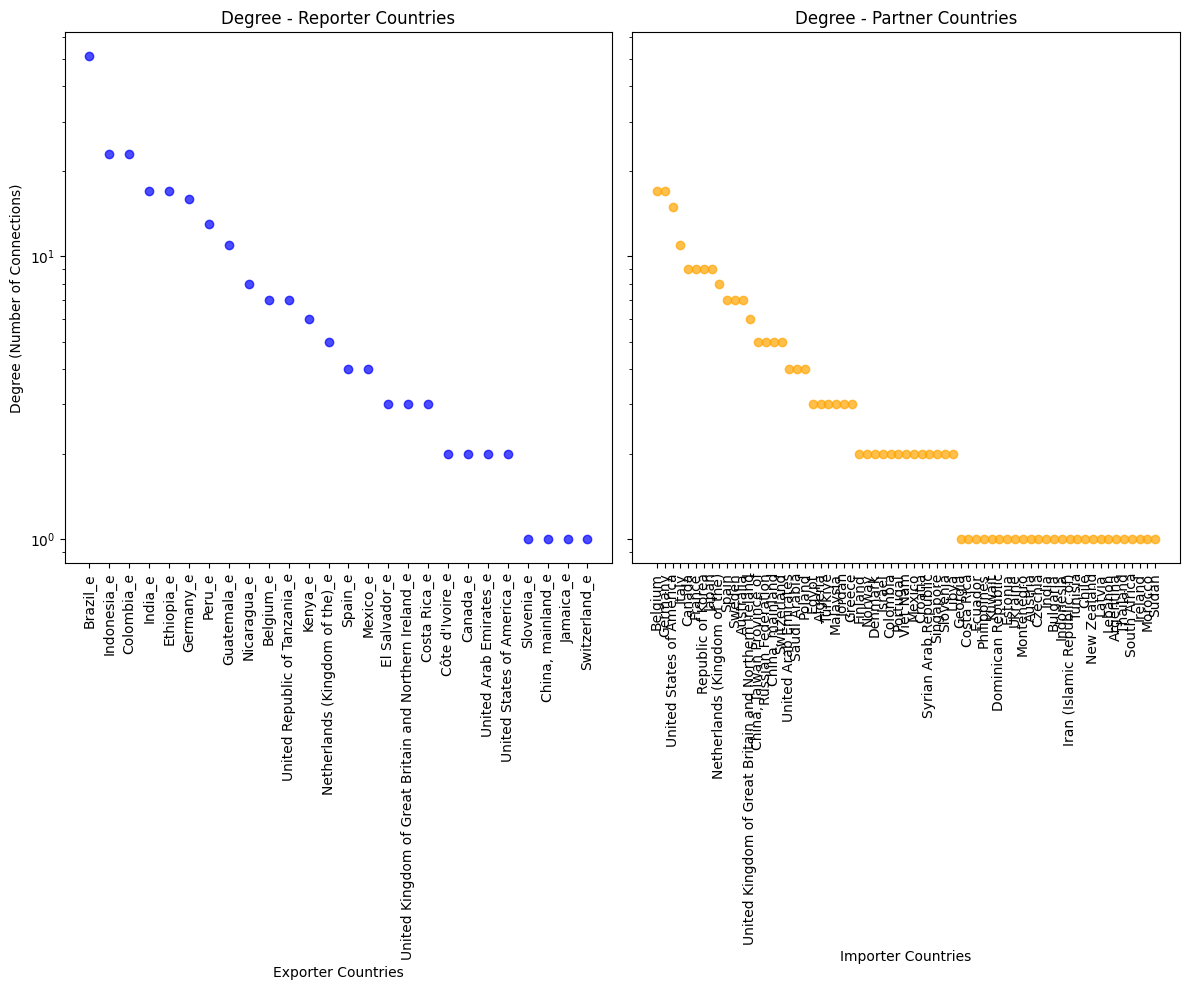

In [32]:
plot_degree_comparison(degree_export, degree_import, reporter_country_col="Node", partner_country_col="Node",use_log_scale=True)

### Combined rank-degree comparison across years

We compare the rank-degree curves for exporters and importers across four years: 1993, 2000, 2010 and 2023.


(<Figure size 1800x800 with 2 Axes>,
 array([<Axes: title={'center': 'Exporters'}, xlabel='Rank', ylabel='Degree'>,
        <Axes: title={'center': 'Importers'}, xlabel='Rank', ylabel='Degree'>],
       dtype=object))

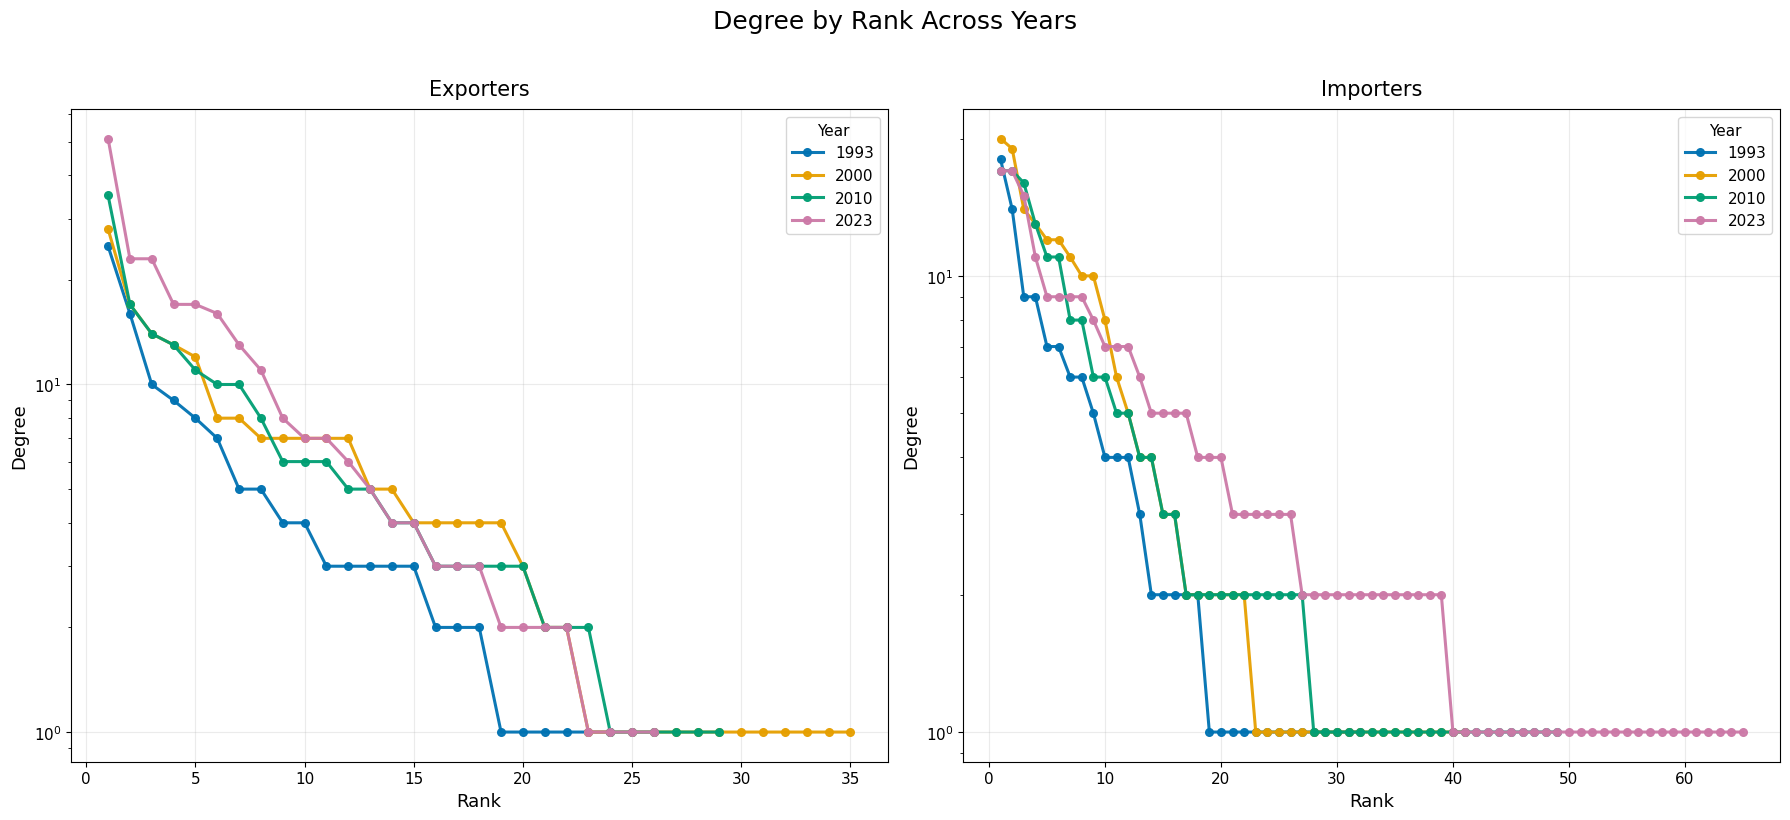

In [11]:
comparison_years = [1993, 2000, 2010, 2023]
degree_export_by_year = {}
degree_import_by_year = {}

for comparison_year in comparison_years:
    df_year = load_file(file, year=comparison_year)
    df_year_filtered = filter_top_percentile(df_year, value_column='Value', percentile=0.9).copy()
    df_year_filtered['Reporter Countries'] = df_year_filtered['Reporter Countries'] + '_e'

    G_year, exporters_year, importers_year = build_bipartite_network(
        df_year_filtered, 'Reporter Countries', 'Partner Countries', 'Value'
    )
    G_year = remove_zero_weight_edges(G_year)

    degree_export_by_year[comparison_year] = degree_by_group(G_year, exporters_year)
    degree_import_by_year[comparison_year] = degree_by_group(G_year, importers_year)

plot_degree_rank_multiyear(
    degree_export_by_year,
    degree_import_by_year,
    years=comparison_years,
    degree_col='Degree',
    figsize=(18, 8),
    use_log_y=True,
    suptitle='Degree by Rank Across Years',
    exporter_title='Exporters',
    importer_title='Importers',
    ylabel='Degree',
    save_path='Degree_years'
)


## Truncated Power-Law Fit of the Degree Distribution

To characterize the shape of the degree distribution, we fit it using a truncated power-law function. This model combines a heavy-tailed behavior with an exponential cutoff, which is often appropriate for empirical trade networks where very highly connected nodes exist, but their degree is still bounded.

In this example, we apply the fit to the importers in 2023. The goal is to evaluate how well a truncated power law reproduces the observed degree-frequency distribution and to provide a first quantitative description of the connectivity pattern in the importer layer.

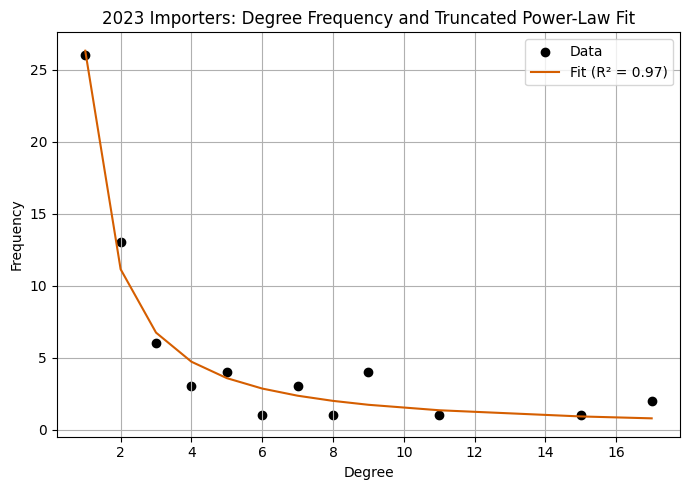

Importer fit for 2023
a = 26.30441490482175
b = 1.2401700525763755
c = 12173115.502497101
R^2 = 0.9678902387145718


In [12]:
# Compute importer degrees
degree_import = degree_by_group(G, importers)
degree_import_sorted = degree_import.sort_values(by="Degree", ascending=False)

# Fit truncated power law to exporter degree distribution
result_exp_2023 = fit_truncated_power_law(
    degree_import_sorted["Degree"].values,
    title="2023 Importers: Degree Frequency and Truncated Power-Law Fit",
    xlabel="Degree",
    ylabel="Frequency",
    show_plot=True,
    figsize=(7, 5),
    color_data="black",
    color_fit="#D55E00",
    save_path="importers_2023_truncated_power_law.png",
    save_dpi=400,
)

# 5. Print parameters
print("Importer fit for 2023")
print("a =", result_exp_2023["parameters"]["a"])
print("b =", result_exp_2023["parameters"]["b"])
print("c =", result_exp_2023["parameters"]["c"])
print("R^2 =", result_exp_2023["r_squared"])

## Strength Analysis

We now move from degree to node strength in the bipartite trade network. While degree counts the number of trade partners, strength measures the total trade volume associated with each country, providing a weighted view of its importance in the network.

In the following cells, we analyze the strength of exporters and importers, compare their distributions, and study how weighted connectivity changes across countries and over time. This helps reveal not only how many connections each country has, but also how economically relevant those connections are.

### Combined strength-rank comparison across years

We compare the rank-strength curves for exporters and importers across four years: 1993, 2000, 2010 and 2023.


(<Figure size 1800x800 with 2 Axes>,
 array([<Axes: title={'center': 'Exporters'}, xlabel='Rank', ylabel='Strength'>,
        <Axes: title={'center': 'Importers'}, xlabel='Rank', ylabel='Strength'>],
       dtype=object))

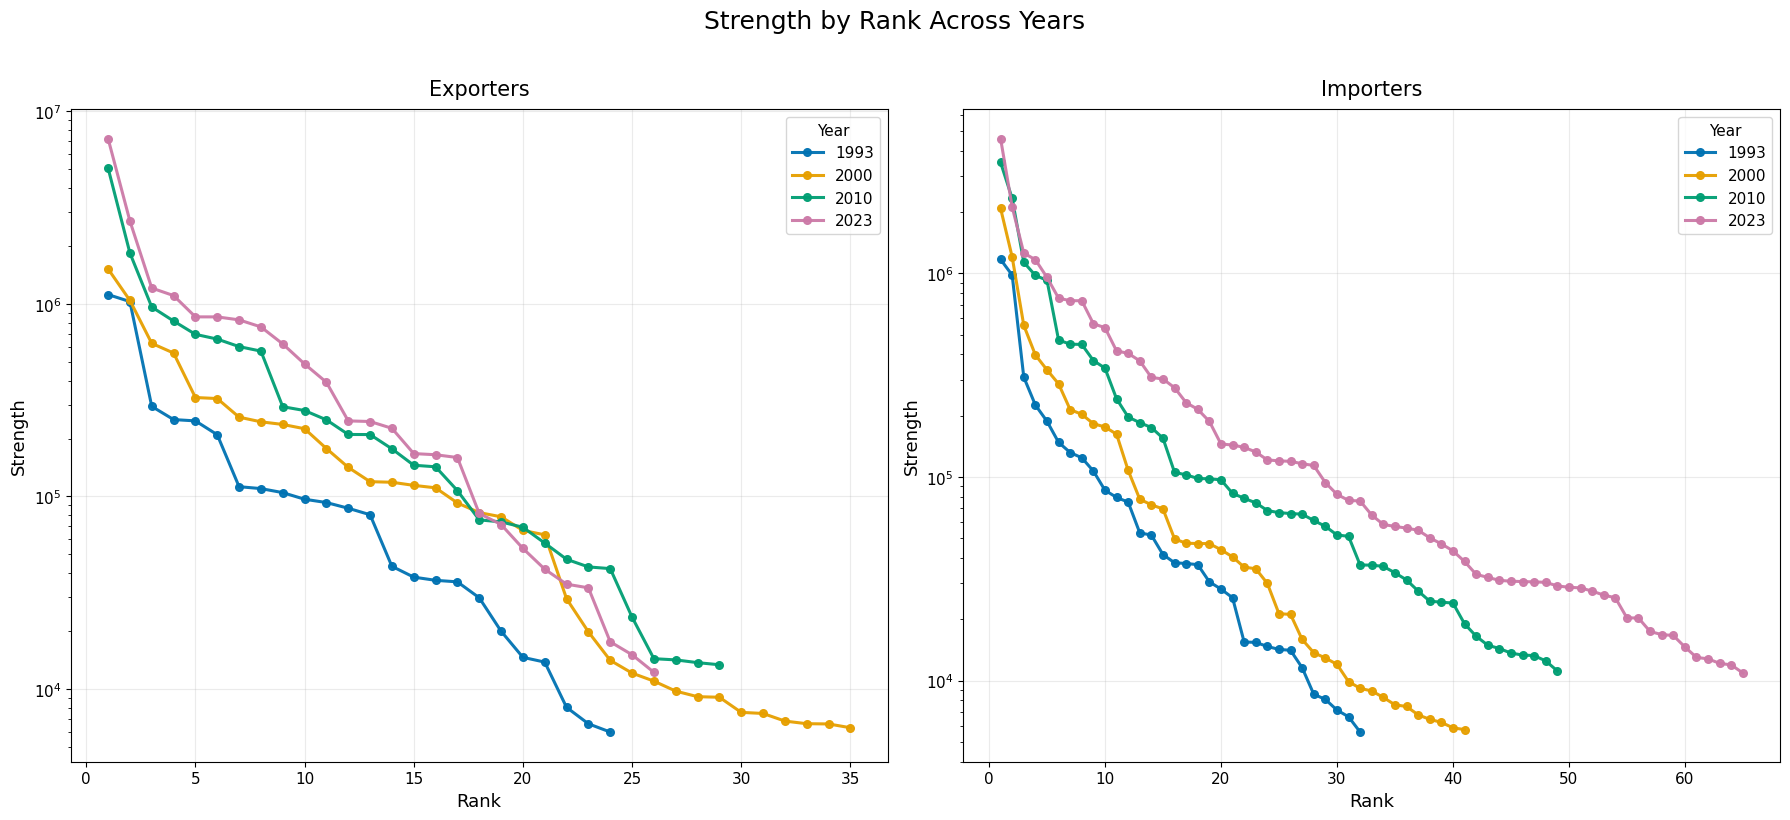

In [13]:
comparison_years = [1993, 2000, 2010, 2023]
strength_export_by_year = {}
strength_import_by_year = {}

for comparison_year in comparison_years:
    df_year = load_file(file, year=comparison_year)
    df_year_filtered = filter_top_percentile(df_year, value_column='Value', percentile=0.9).copy()
    df_year_filtered['Reporter Countries'] = df_year_filtered['Reporter Countries'] + '_e'

    G_year, exporters_year, importers_year = build_bipartite_network(
        df_year_filtered, 'Reporter Countries', 'Partner Countries', 'Value'
    )
    G_year = remove_zero_weight_edges(G_year)

    df_exporters_year, df_importers_year = compute_degree_and_strength(
        G_year, exporters_year, importers_year
    )

    strength_export_by_year[comparison_year] = df_exporters_year
    strength_import_by_year[comparison_year] = df_importers_year

plot_degree_rank_multiyear(
    strength_export_by_year,
    strength_import_by_year,
    years=comparison_years,
    degree_col='Strength',
    figsize=(18, 8),
    use_log_y=True,
    suptitle='Strength by Rank Across Years',
    exporter_title='Exporters',
    importer_title='Importers',
    ylabel='Strength',
    save_path='Strength_years'
)


### Combined strength-rank comparison across years

We compare the rank-strength curves for exporters and importers across four years: 1993, 2000, 2010 and 2023.


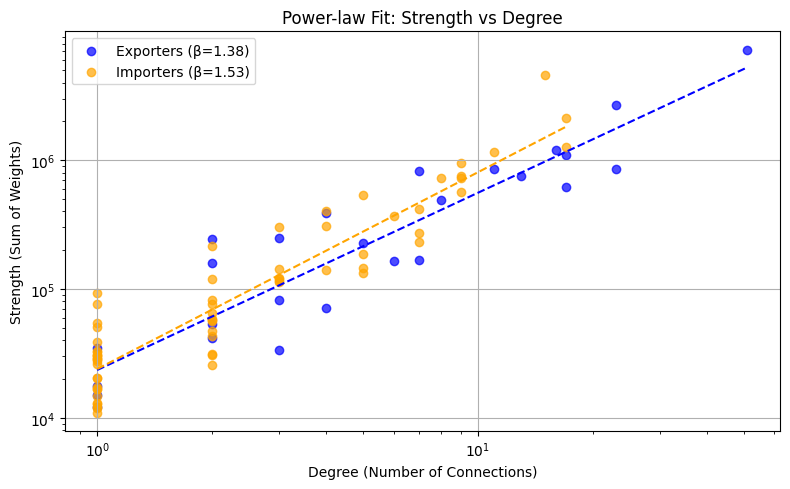

1.3763041305644568 0.8503064891224954


In [14]:
df_exporters, df_importers = compute_degree_and_strength(G, exporters, importers)

result = fit_strength_vs_degree(
    df_exporters,
    df_importers,
    save_path="strength_vs_degree_2023.png",
    save_dpi=400,
)

print(result["exporters"]["slope"], result["exporters"]["r_squared"])


When we represent strength vs. degree, they behave like a power law. If the exponent is 1, it means that the distribution of weights is completely random based on the degree. Since the exponent $α$ is greater than 1 in both cases, this suggests that countries with a higher degree have a greater strength than would correspond to them randomly. Therefore, the market is concentrated in countries with a higher degree.

## Weighted matrix
We plot the weighted matrix on a heatmap to see the interaction. It is confirmed that the core of interactions also has a greater weight (as seen in the color of the interactions).

In [15]:
year = 2023
df = load_file(file, year = year)
df_filtered = filter_top_percentile(df, value_column= 'Value', percentile=0.9)

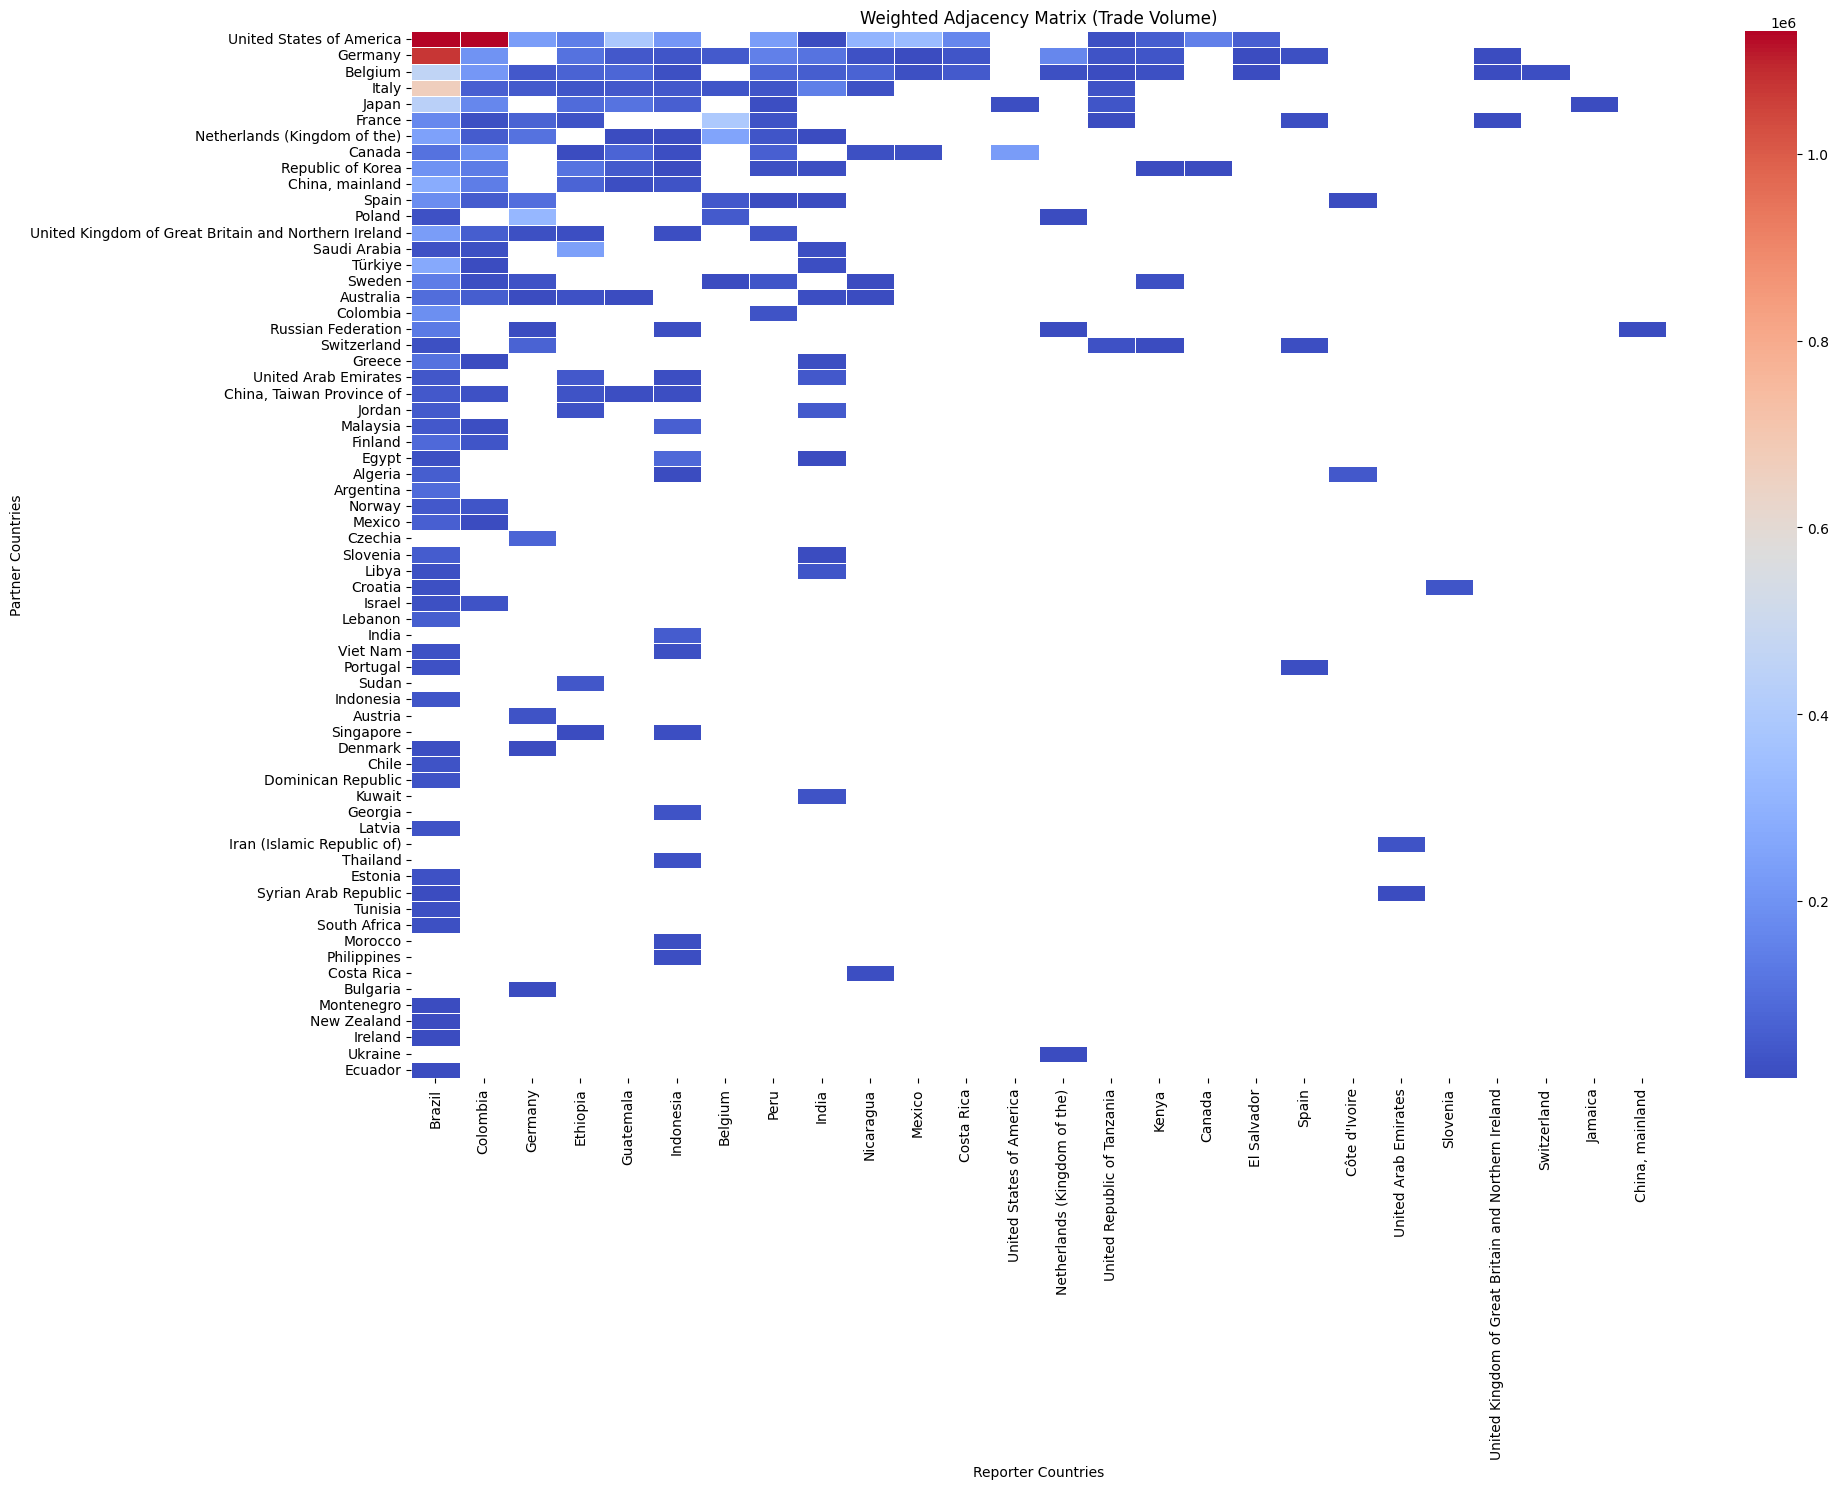

<Axes: title={'center': 'Weighted Adjacency Matrix (Trade Volume)'}, xlabel='Reporter Countries', ylabel='Partner Countries'>

In [16]:
plot_weight_matrix(
    df_filtered,
    save_path="weighted_matrix2023.png",
    save_dpi=400,
)


## Clustering Coefficient

So far, we have focused on node-level properties such as degree and strength. To characterize the local structural organization of the network, we now consider the clustering coefficient. This measure is relevant because local clustering can affect how rapidly shocks propagate through a network (Pastor-Satorras and Vespignani, 2001). In the context of the international coffee market, it is therefore useful for understanding the potential transmission of disturbances such as production failures.

In unipartite networks, clustering is based on the abundance of triangles relative to the number of triangles that could potentially be formed. In bipartite networks, however, triangles are not possible because links only connect nodes from different groups. For this reason, bipartite clustering is instead defined in terms of closed cycles of length four. Here we follow the approach proposed by Gilarranz et al. (2012), which extends the clustering concept to bipartite structures.

The ratio between weighted and unweighted bipartite clustering provides additional information about whether local closed structures are reinforced by strong trade links. Values that are systematically higher for one node class indicate that its local quadrilateral structures tend to be supported by more intense trade flows.

In [17]:
df_c4b = compute_bipartite_clustering(G, reporters=exporters)
df_c4b.head()

,node,C4b,C4b^w,degree,C4_rate,tipo
0,Canada_e,0.571429,0.285714,2,0.500000,Exportador
1,Belgium_e,0.240741,0.035545,7,0.147649,Exportador
2,United Arab Emirates_e,0.000000,0.000000,2,NaN,Exportador
3,Switzerland_e,0.000000,0.000000,1,NaN,Exportador
4,Peru_e,0.213869,0.020143,13,0.094185,Exportador


<Axes: title={'center': 'Mean clustering ratio ⟨C4b^w / C4b⟩ vs. Degree by node type'}, xlabel='Degree', ylabel='⟨C4b^w / C4b⟩'>

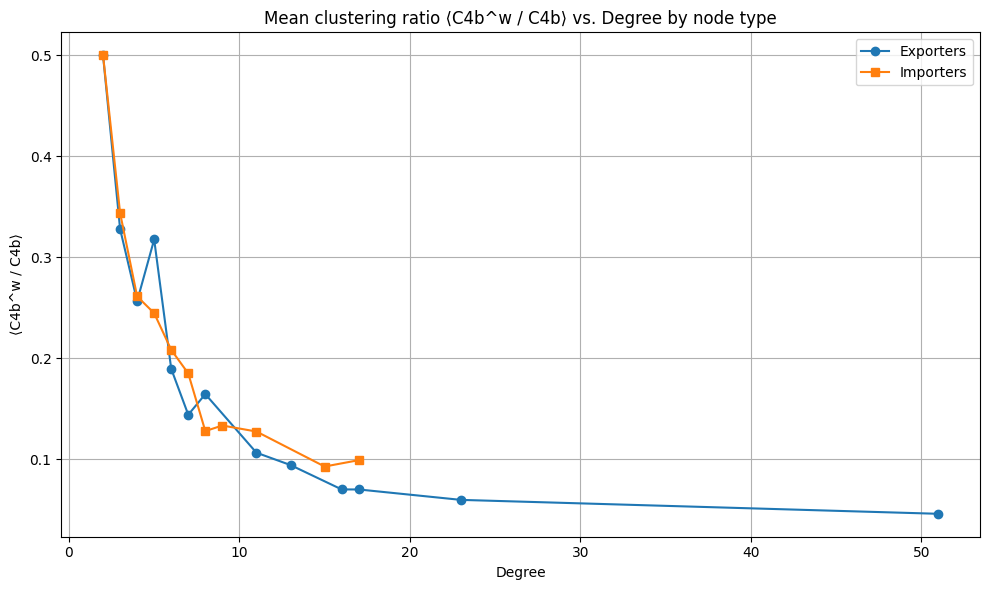

In [18]:
plot_mean_clustering_ratio_vs_degree(
    df_c4b,
    show_labels=False,
    label_max_names_per_line=2,
    label_font_size=5,
    save_path="clustering_ratio_2023.png",
    save_dpi=400,
)


A useful interpretation is the following: highly connected nodes may participate in many quadrilateral structures without those structures being equally strong in weighted terms. For example, a major exporter such as Brazil may trade with several large importers, but those importers do not necessarily share equally strong connections with the same set of exporters. In that case, quadrilateral structures exist, but they are not reinforced uniformly by weight.

(<Figure size 1600x600 with 2 Axes>,
 array([<Axes: title={'center': 'Exporters'}, xlabel='Degree', ylabel='Mean C4b^w / C4b'>,
        <Axes: title={'center': 'Importers'}, xlabel='Degree', ylabel='Mean C4b^w / C4b'>],
       dtype=object))

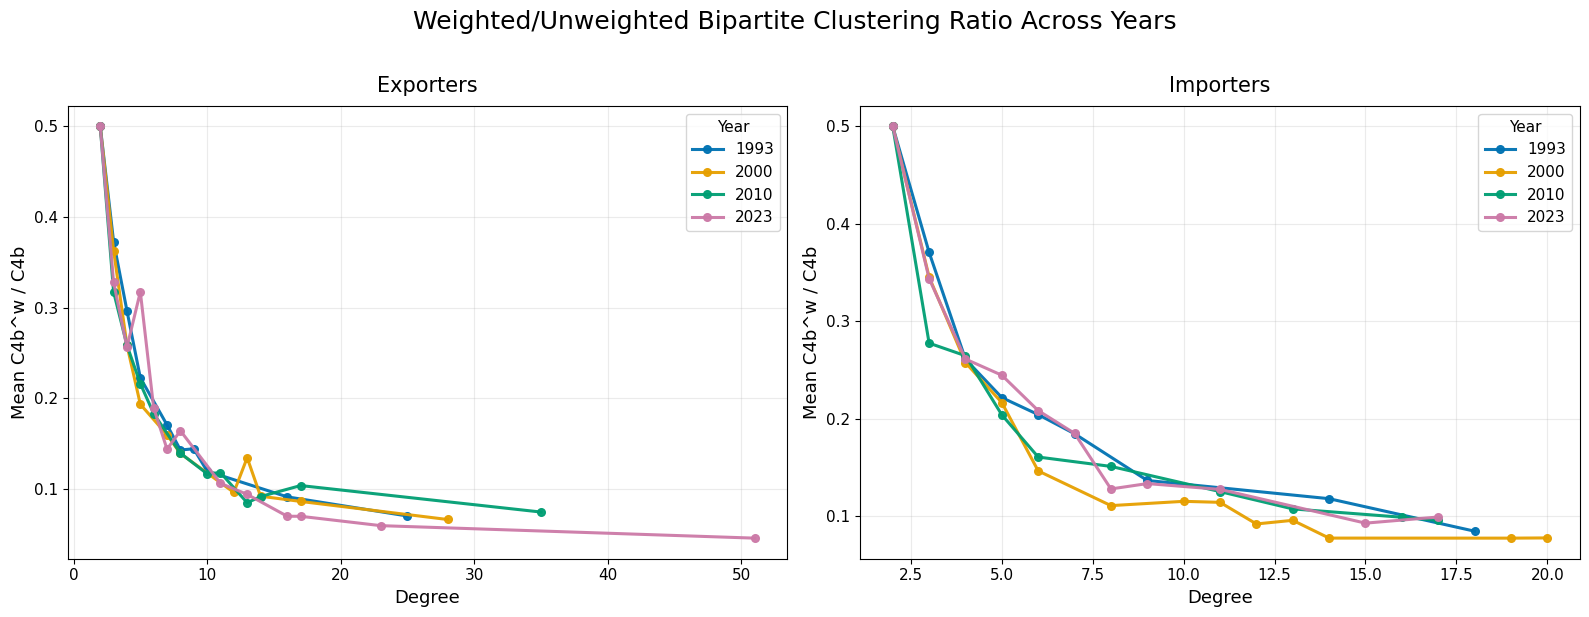

In [19]:
comparison_years = [1993, 2000, 2010, 2023]
clustering_by_year = {}

for comparison_year in comparison_years:
    df_year = load_file(file, year=comparison_year)
    df_year_filtered = filter_top_percentile(df_year, value_column="Value", percentile=0.9).copy()
    df_year_filtered["Reporter Countries"] = df_year_filtered["Reporter Countries"] + "_e"

    G_year, exporters_year, importers_year = build_bipartite_network(
        df_year_filtered,
        "Reporter Countries",
        "Partner Countries",
        "Value"
    )
    G_year = remove_zero_weight_edges(G_year)

    df_c4_year = compute_bipartite_clustering(G_year, reporters=exporters_year)
    clustering_by_year[comparison_year] = df_c4_year

plot_clustering_ratio_multiyear(
    clustering_by_year,
    years=comparison_years,
    suptitle="Weighted/Unweighted Bipartite Clustering Ratio Across Years",
    exporter_title="Exporters",
    importer_title="Importers",
    xlabel="Degree",
    ylabel="Mean C4b^w / C4b",
    figsize=(16, 6),
    save_path="clustering_ratio_multiyear.png",
    save_dpi=400,
)


## Betweenness

Another interesting property to study in networks is **betweenness**.

About calculating betweenness centrality in bipartite networks

In theory, the NetworkX betweenness centrality algorithm works on any network. However:
- If we apply it directly to the bipartite network, we obtain paths that only respect the original structure (without projection).
- If we project the network onto one of the sets (for example, only exporters), we can interpret how nodes of the same type are indirectly related through the other set.

In [20]:
df_bet = compute_betweenness_all(G)
title = "betweenness_centrality_"+ str(year) + ".csv"
df_bet.to_csv(title, index=False)
df_bet.head()

,node,bipartite_set,betweenness_bipartite,betweenness_bipartite_inv,betweenness_proj_exporters,betweenness_proj_exporters_inv,betweenness_proj_importers,betweenness_proj_importers_inv
0,Canada_e,0,0.000000,0.000000,0.027907,0.000000,NaN,NaN
1,Belgium_e,0,0.000499,0.000499,0.014899,0.000000,NaN,NaN
2,United Arab Emirates_e,0,0.022222,0.022222,0.000000,0.000000,NaN,NaN
3,Switzerland_e,0,0.000000,0.000000,0.408573,0.000000,NaN,NaN
4,Peru_e,0,0.076155,0.000000,0.011134,0.009456,NaN,NaN


**Recommendation**
- Use "weight" when the weights represent costs, distances, or times.
- Use "inv_weight" when the weights represent volume, frequency, or value (as in the case of coffee).

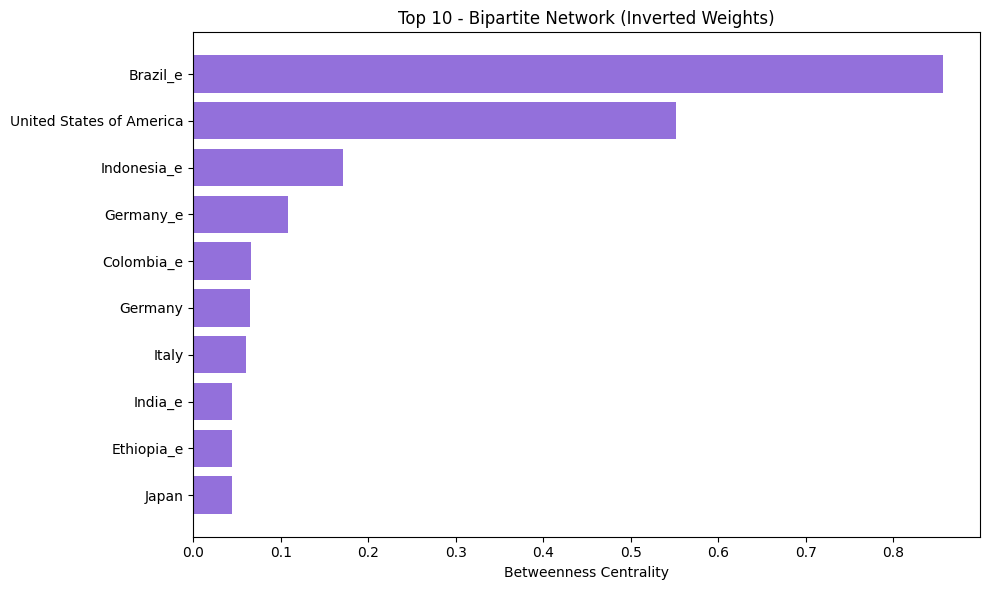

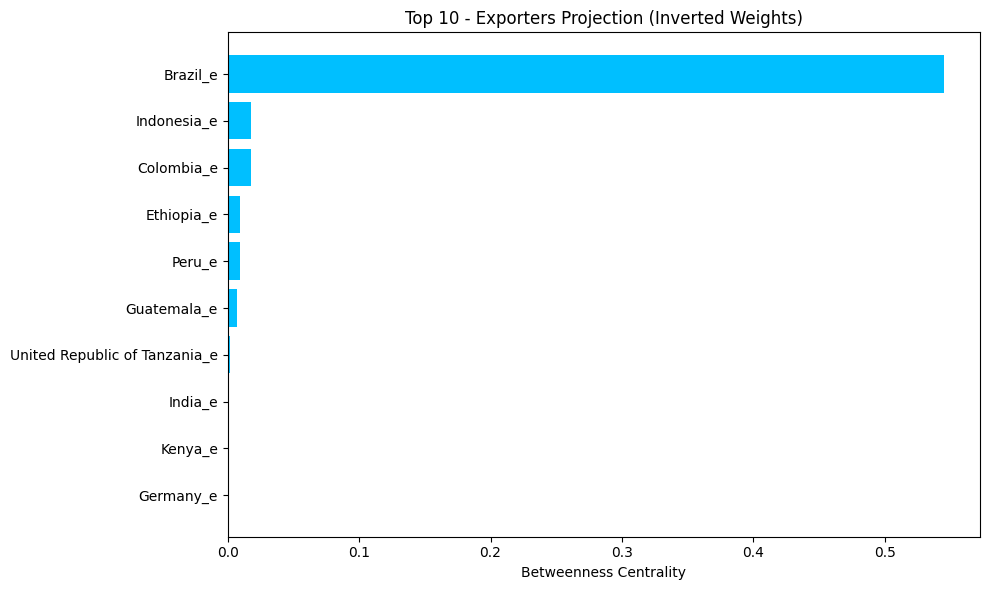

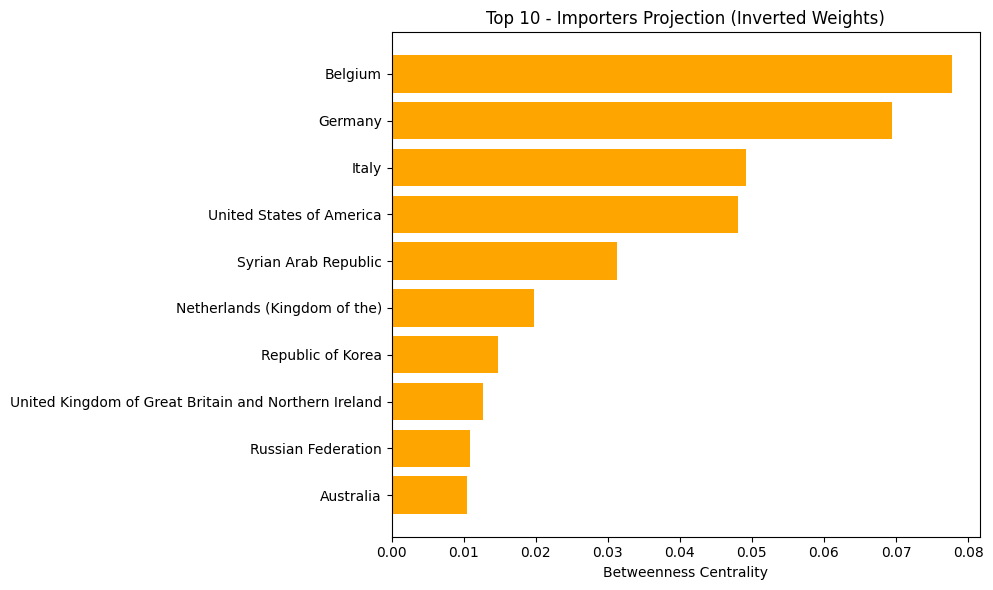

<Axes: title={'center': 'Top 10 - Importers Projection (Inverted Weights)'}, xlabel='Betweenness Centrality'>

In [21]:
plot_top_betweenness(df_bet, "betweenness_bipartite_inv", "Top 10 - Bipartite Network (Inverted Weights)", "mediumpurple")
plot_top_betweenness(df_bet, "betweenness_proj_exporters_inv", "Top 10 - Exporters Projection (Inverted Weights)", "deepskyblue")
plot_top_betweenness(df_bet, "betweenness_proj_importers_inv", "Top 10 - Importers Projection (Inverted Weights)", "orange")

If the inverted value of the peso is used.

🟣 Bipartite network: - Nodes that act as effective bridges between exporters and importers, considering the economic value of trade. - High peso = lower cost of the routes → higher probability of passing through that node.

🔵 Exporter projection: - Identifies exporters that are located in the middle of intense trade routes between other exporters. - Represents a type of indirect trade mediation.

🟢 Importer projection: - Similar, but focused on importers that share key suppliers and are located on higher-volume routes.

year,1993,2000,2010,2023
node,,,,
Brazil_e,1.0,1.0,1.0,1.0
Colombia_e,2.0,2.0,4.0,3.0
Indonesia_e,6.0,4.0,3.0,2.0
Guatemala_e,3.0,3.0,5.0,6.0
Ethiopia_e,NaN,6.0,6.0,4.0
Papua New Guinea_e,7.0,NaN,NaN,NaN
Costa Rica_e,5.0,5.0,6.0,12.0
Peru_e,10.0,13.0,2.0,4.0
El Salvador_e,8.0,8.0,11.0,12.0


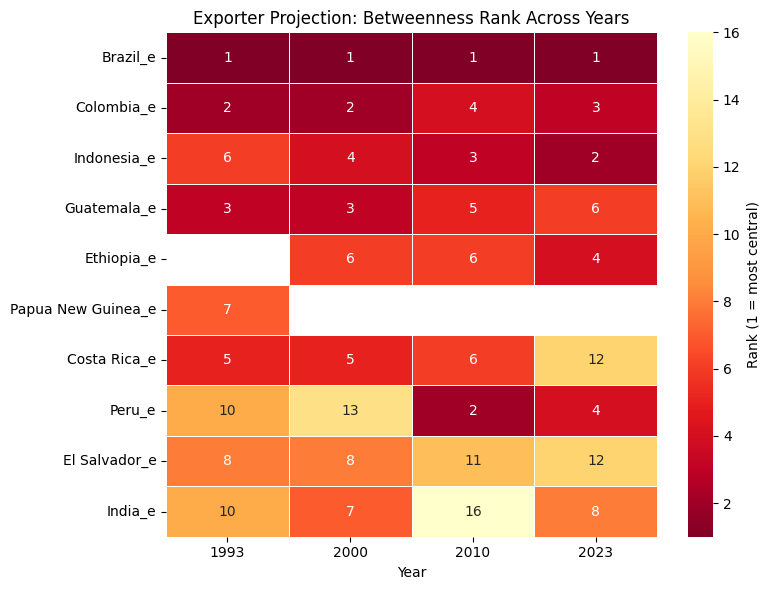

In [28]:
comparison_years = [1993, 2000, 2010, 2023]
betweenness_by_year = {}

for comparison_year in comparison_years:
    df_year = load_file(file, year=comparison_year)
    df_year_filtered = filter_top_percentile(df_year, value_column="Value", percentile=0.9).copy()
    df_year_filtered["Reporter Countries"] = df_year_filtered["Reporter Countries"] + "_e"

    G_year, exporters_year, importers_year = build_bipartite_network(
        df_year_filtered,
        "Reporter Countries",
        "Partner Countries",
        "Value"
    )
    G_year = remove_zero_weight_edges(G_year)

    betweenness_by_year[comparison_year] = compute_betweenness_all(G_year)

ax, matrix = plot_betweenness_heatmap(
    betweenness_by_year,
    metric_col="betweenness_proj_exporters_inv",
    years=comparison_years,
    mode="rank",
    top_n=10,
    cmap="YlOrRd_r",
    figsize=(8, 6),
    title="Exporter Projection: Betweenness Rank Across Years",
    cbar_label="Rank (1 = most central)",
    save_path="betweenness_exporters_heatmap.png",
    save_dpi=400,
)

matrix


## Appendix: Model comparison for degree distributions

In this appendix, we compare the truncated power-law fit against alternative candidate distributions for the degree distributions of exporters and importers. These additional checks complement the main analysis and provide a more formal basis for model selection.


In [23]:
!pip install powerlaw

Number of exporters: 26
Min degree: 1
Max degree: 51
Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 12/12 [00:00<00:00, 1422.80it/s]


Best-fit xmin: 2.0
Estimated alpha (power law): 1.686648365449246
Estimated sigma: 0.1463939233981882

Model comparisons
Positive R favors the first model; negative R favors the second.
Small p-values suggest the preference is statistically meaningful.



power_law vs truncated_power_law: R = -3.2856, p = 0.0104
power_law vs lognormal: R = -2.8687, p = 0.1386
power_law vs exponential: R = -2.1458, p = 0.5364
truncated_power_law vs lognormal: R = 0.4169, p = 0.3526
truncated_power_law vs exponential: R = 1.1398, p = 0.4652
lognormal vs exponential: R = 0.7229, p = 0.6643


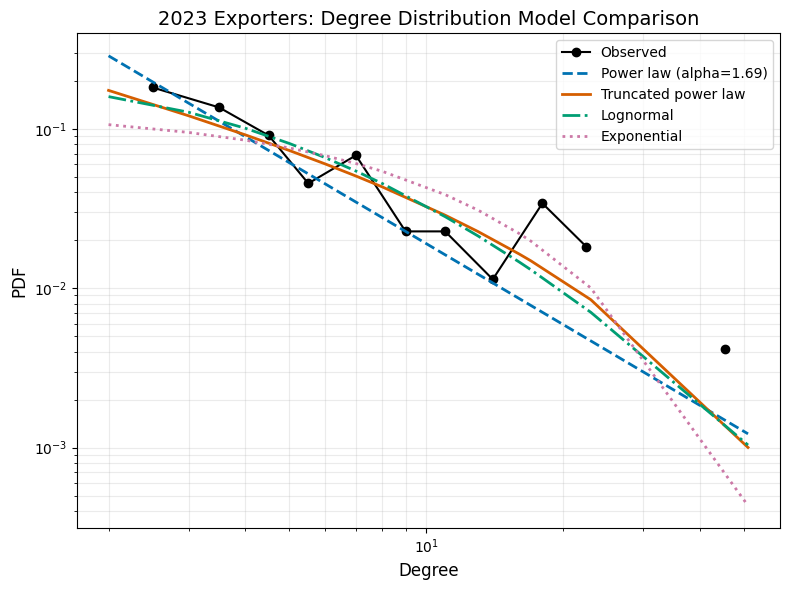

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import powerlaw

from faonet.io import load_file
from faonet.filtering import filter_top_percentile
from faonet.network import build_bipartite_network, remove_zero_weight_edges
from faonet.metrics import degree_by_group

# 1. Load and preprocess data
file = "examples/Data/Green_Coffe_FAO_allyears.csv"
year = 2023

df = load_file(file, year=year)
df_filtered = filter_top_percentile(df, value_column="Value", percentile=0.9).copy()
df_filtered["Reporter Countries"] = df_filtered["Reporter Countries"] + "_e"

# 2. Build network
G, exporters, importers = build_bipartite_network(
    df_filtered,
    "Reporter Countries",
    "Partner Countries",
    "Value"
)
G = remove_zero_weight_edges(G)

# 3. Exporter degrees
degree_export = degree_by_group(G, exporters)
degrees = degree_export["Degree"].values
degrees = degrees[degrees > 0]

print(f"Number of exporters: {len(degrees)}")
print(f"Min degree: {degrees.min()}")
print(f"Max degree: {degrees.max()}")

# 4. Fit distributions
fit = powerlaw.Fit(degrees, discrete=True)

print("\nBest-fit xmin:", fit.xmin)
print("Estimated alpha (power law):", fit.alpha)
print("Estimated sigma:", fit.sigma)

# 5. Compare models
comparisons = [
    ("power_law", "truncated_power_law"),
    ("power_law", "lognormal"),
    ("power_law", "exponential"),
    ("truncated_power_law", "lognormal"),
    ("truncated_power_law", "exponential"),
    ("lognormal", "exponential"),
]

print("\nModel comparisons")
print("Positive R favors the first model; negative R favors the second.")
print("Small p-values suggest the preference is statistically meaningful.\n")

for model1, model2 in comparisons:
    R, p = fit.distribution_compare(model1, model2)
    print(f"{model1} vs {model2}: R = {R:.4f}, p = {p:.4f}")

# 6. Plot PDF comparison
fig = plt.figure(figsize=(8, 6))

fit.plot_pdf(
    color="black",
    marker="o",
    markersize=6,
    linewidth=1.5,
    label="Observed"
)

fit.power_law.plot_pdf(
    color="#0072B2",
    linestyle="--",
    linewidth=2,
    label=f"Power law (alpha={fit.power_law.alpha:.2f})"
)

fit.truncated_power_law.plot_pdf(
    color="#D55E00",
    linestyle="-",
    linewidth=2,
    label="Truncated power law"
)

fit.lognormal.plot_pdf(
    color="#009E73",
    linestyle="-.",
    linewidth=2,
    label="Lognormal"
)

fit.exponential.plot_pdf(
    color="#CC79A7",
    linestyle=":",
    linewidth=2,
    label="Exponential"
)

plt.xlabel("Degree", fontsize=12)
plt.ylabel("PDF", fontsize=12)
plt.title("2023 Exporters: Degree Distribution Model Comparison", fontsize=14)
plt.legend(frameon=True)
plt.grid(True, which="both", alpha=0.25)
plt.tight_layout()
plt.savefig('Comparison_Exporters2023', dpi=400)
plt.show()



Number of importers: 65
Min degree: 1
Max degree: 17
Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 10/10 [00:00<00:00, 1326.09it/s]


Best-fit xmin: 2.0
Estimated alpha (power law): 2.0334642815147688
Estimated sigma: 0.16548672742246076

Model comparisons
Positive R favors the first model; negative R favors the second.
Small p-values suggest the preference is statistically meaningful.



power_law vs truncated_power_law: R = -3.5528, p = 0.0077
power_law vs lognormal: R = -2.8388, p = 0.1360
power_law vs exponential: R = -2.7817, p = 0.3679
truncated_power_law vs lognormal: R = 0.7140, p = 0.0317
truncated_power_law vs exponential: R = 0.7711, p = 0.4860
lognormal vs exponential: R = 0.0571, p = 0.9628


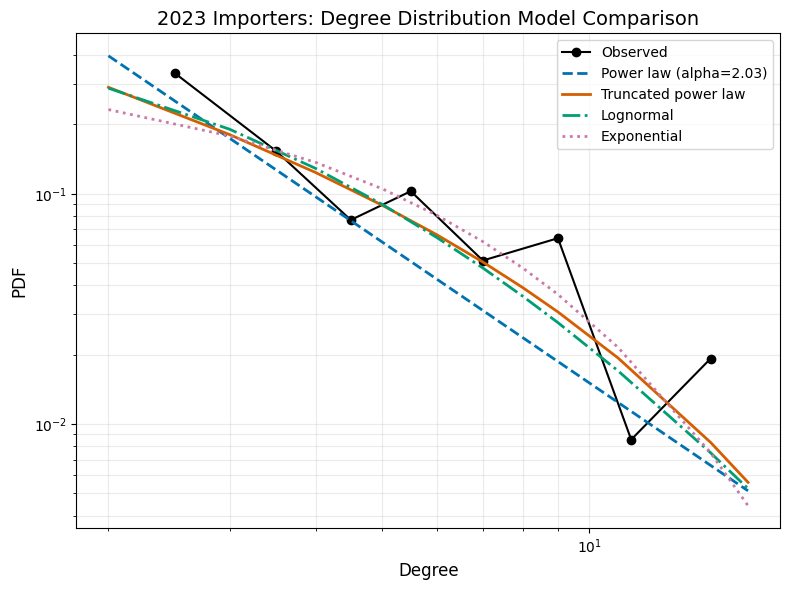

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import powerlaw

from faonet.io import load_file
from faonet.filtering import filter_top_percentile
from faonet.network import build_bipartite_network, remove_zero_weight_edges
from faonet.metrics import degree_by_group

# 1. Load and preprocess data
file = "examples/Data/Green_Coffe_FAO_allyears.csv"
year = 2023

df = load_file(file, year=year)
df_filtered = filter_top_percentile(df, value_column="Value", percentile=0.9).copy()
df_filtered["Reporter Countries"] = df_filtered["Reporter Countries"] + "_e"

# 2. Build network
G, exporters, importers = build_bipartite_network(
    df_filtered,
    "Reporter Countries",
    "Partner Countries",
    "Value"
)
G = remove_zero_weight_edges(G)

# 3. Importer degrees
degree_import = degree_by_group(G, importers)
degrees = degree_import["Degree"].values
degrees = degrees[degrees > 0]

print(f"Number of importers: {len(degrees)}")
print(f"Min degree: {degrees.min()}")
print(f"Max degree: {degrees.max()}")

# 4. Fit distributions
fit = powerlaw.Fit(degrees, discrete=True)

print("\nBest-fit xmin:", fit.xmin)
print("Estimated alpha (power law):", fit.alpha)
print("Estimated sigma:", fit.sigma)

# 5. Compare models
comparisons = [
    ("power_law", "truncated_power_law"),
    ("power_law", "lognormal"),
    ("power_law", "exponential"),
    ("truncated_power_law", "lognormal"),
    ("truncated_power_law", "exponential"),
    ("lognormal", "exponential"),
]

print("\nModel comparisons")
print("Positive R favors the first model; negative R favors the second.")
print("Small p-values suggest the preference is statistically meaningful.\n")

for model1, model2 in comparisons:
    R, p = fit.distribution_compare(model1, model2)
    print(f"{model1} vs {model2}: R = {R:.4f}, p = {p:.4f}")

# 6. Plot PDF comparison
fig = plt.figure(figsize=(8, 6))

fit.plot_pdf(
    color="black",
    marker="o",
    markersize=6,
    linewidth=1.5,
    label="Observed"
)

fit.power_law.plot_pdf(
    color="#0072B2",
    linestyle="--",
    linewidth=2,
    label=f"Power law (alpha={fit.power_law.alpha:.2f})"
)

fit.truncated_power_law.plot_pdf(
    color="#D55E00",
    linestyle="-",
    linewidth=2,
    label="Truncated power law"
)

fit.lognormal.plot_pdf(
    color="#009E73",
    linestyle="-.",
    linewidth=2,
    label="Lognormal"
)

fit.exponential.plot_pdf(
    color="#CC79A7",
    linestyle=":",
    linewidth=2,
    label="Exponential"
)

plt.xlabel("Degree", fontsize=12)
plt.ylabel("PDF", fontsize=12)
plt.title("2023 Importers: Degree Distribution Model Comparison", fontsize=14)
plt.legend(frameon=True)
plt.grid(True, which="both", alpha=0.25)
plt.tight_layout()
plt.savefig('Comparison_Importers2023', dpi=400)
plt.show()
